In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
# Define time-varying Voltage
def V_of_t(t):
    if t < 500:
        return 3.0
    elif t < 1000:
        return 4.0
    elif t < 1500:
        return 3.5
    else:
        return 4.5

In [3]:
# Define the physics-based functions
def inflow_rate(V):
    return (4.0423 * V - 2.8661) * 1e-6

def outflow_rate(h, Cf, d, g, h0):
    h_diff = torch.maximum(h - h0, torch.tensor(0.0, device=h.device, dtype=h.dtype))
    return Cf * (np.pi / 4) * d**2 * torch.sqrt(2 * g * h_diff)

def area_of_tank(h, R):
    return torch.pi * (2 * R * h - h**2)

In [4]:
# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # Input: [h_prev, u_current]
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)   # Output: h_next
        )

    def forward(self, h_prev, u_current):
        inputs = torch.cat((h_prev, u_current), dim=1)
        return self.net(inputs)

In [5]:
# Physics-informed loss function
def loss_function(model, h_prev, u_current, h_true, R, Cf, d, g, h0):
    # Data loss
    h_pred = model(h_prev, u_current)
    data_loss = torch.mean((h_pred - h_true)**2)

    # Physics-informed loss
    h_pred.requires_grad_(True)
    dhdt_pred = torch.autograd.grad(
        outputs=model(h_prev, u_current),
        inputs=h_prev,
        grad_outputs=torch.ones_like(h_pred),
        create_graph=True
    )[0]

    Qin = inflow_rate(u_current)
    Qout = outflow_rate(h_pred, Cf, d, g, h0)
    A = area_of_tank(h_pred, R)
    physics_loss = torch.mean((dhdt_pred - (Qin - Qout) / A)**2)

    # Total loss
    return data_loss + physics_loss

In [6]:
# Updated training setup
def train_pinn_with_voltage(model, optimizer, h_prev, h_true, R, Cf, d, g, h0, epochs=1000):
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Compute time-varying voltage
        t = epoch % len(h_prev)  # Assuming cyclic voltage over time
        voltage_value = V_of_t(t)
        u_current = torch.full_like(h_prev, voltage_value, dtype=torch.float32)  # Match shape of h_prev

        # Compute loss
        loss = loss_function(model, h_prev, u_current, h_true, R, Cf, d, g, h0)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    return model

In [7]:
# Generate synthetic data
np.random.seed(42)
torch.manual_seed(42)
t_data = np.linspace(0, 10, 100).reshape(-1, 1)
V_data = 5 + np.sin(0.5 * t_data).reshape(-1, 1)  # Voltage signal
h_data = 0.5 + 0.1 * np.sin(0.5 * t_data).reshape(-1, 1)  # Simulated height

In [8]:
# Normalize data
scaler_V = MinMaxScaler()
scaler_h = MinMaxScaler()
V_data_scaled = scaler_V.fit_transform(V_data)
h_data_scaled = scaler_h.fit_transform(h_data)

In [9]:
# Prepare sequential data
sequence_length = 10  # Use only the previous timestep
h_prev_data = h_data_scaled[:-sequence_length]
u_current_data = V_data_scaled[sequence_length:]
h_true_data = h_data_scaled[sequence_length:]

In [10]:
# Convert data to PyTorch tensors with requires_grad=True for h_prev
h_prev = torch.tensor(h_prev_data, dtype=torch.float32, requires_grad=True)
u_current = torch.tensor(u_current_data, dtype=torch.float32)  # No gradient tracking needed for inputs
h_true = torch.tensor(h_true_data, dtype=torch.float32)

In [11]:
# Hyperparameters and model initialization
R, Cf, d, g, h0 = 0.185, 0.375, 0.008, 9.81, 0.025  # Example physical parameters
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Train the PINN with time-varying Voltage
model = train_pinn_with_voltage(model, optimizer, h_prev, h_true, R, Cf, d, g, h0)

Epoch 0, Loss: 0.14547012746334076
Epoch 10, Loss: 0.13146820664405823
Epoch 20, Loss: 0.12937991321086884
Epoch 30, Loss: 0.12905852496623993
Epoch 40, Loss: 0.12877331674098969
Epoch 50, Loss: 0.12868613004684448
Epoch 60, Loss: 0.12859246134757996
Epoch 70, Loss: 0.1285335272550583
Epoch 80, Loss: 0.12848211824893951
Epoch 90, Loss: 0.1284342110157013
Epoch 100, Loss: 0.1283867359161377
Epoch 110, Loss: 0.12833745777606964
Epoch 120, Loss: 0.12828509509563446
Epoch 130, Loss: 0.1282293051481247
Epoch 140, Loss: 0.12816932797431946
Epoch 150, Loss: 0.12810461223125458
Epoch 160, Loss: 0.12803427875041962
Epoch 170, Loss: 0.12795734405517578
Epoch 180, Loss: 0.12787236273288727
Epoch 190, Loss: 0.12777751684188843
Epoch 200, Loss: 0.12767046689987183
Epoch 210, Loss: 0.1275482326745987
Epoch 220, Loss: 0.12740713357925415
Epoch 230, Loss: 0.12724292278289795
Epoch 240, Loss: 0.12705108523368835
Epoch 250, Loss: 0.1268274188041687
Epoch 260, Loss: 0.12656882405281067
Epoch 270, Loss: 0

In [13]:
# Evaluate the model
with torch.no_grad():
    h_pred = model(h_prev, u_current).numpy()
    h_pred_rescaled = scaler_h.inverse_transform(h_pred)
    h_true_rescaled = scaler_h.inverse_transform(h_true)

In [14]:
# Compare with LSTM results
rmse_pinn = np.sqrt(mean_squared_error(h_true_rescaled, h_pred_rescaled))
print(f"PINN RMSE: {rmse_pinn:.4f}")

PINN RMSE: 0.1511


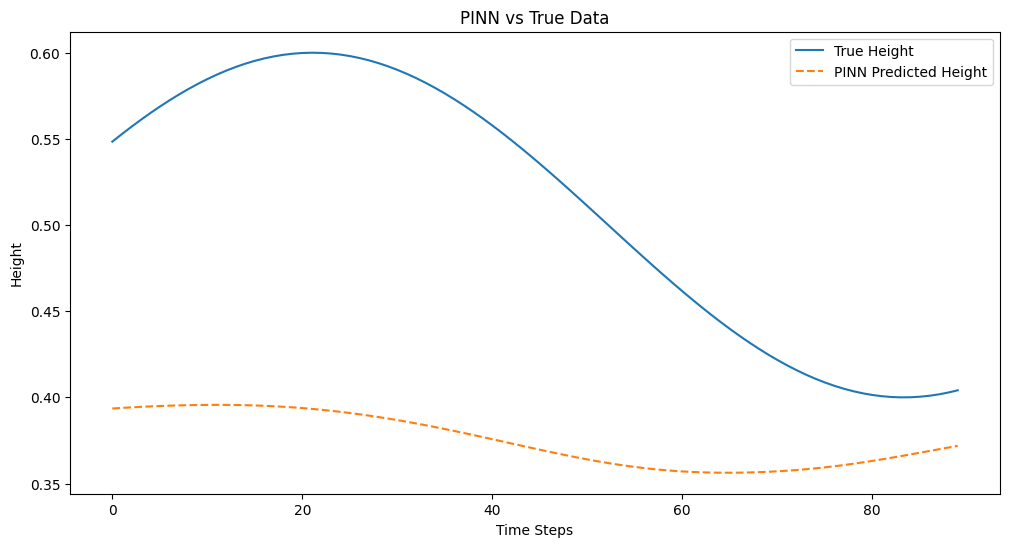

In [15]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(h_true_rescaled, label="True Height")
plt.plot(h_pred_rescaled, label="PINN Predicted Height", linestyle="dashed")
plt.legend()
plt.xlabel("Time Steps")
plt.ylabel("Height")
plt.title("PINN vs True Data")
plt.show()

In [ ]:
torch.save(model.state_dict(), "pinn_model.pth")
print("Model saved successfully as pinn_model.pth")

Model saved successfully as pinn_model.pth
